In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("big_startup_secsees_dataset.csv")

In [3]:
df.head(15)

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24
5,/organization/01games-technology,01Games Technology,http://www.01games.hk/,Games,41250,operating,HKG,NaN,Hong Kong,Hong Kong,1,NaN,2014-07-01,2014-07-01
6,/organization/0ndine-biomedical-inc,Ondine Biomedical Inc.,http://ondinebio.com,Biotechnology,762851,operating,CAN,BC,Vancouver,Vancouver,2,1997-01-01,2009-09-11,2009-12-21
7,/organization/0xdata,H2O.ai,http://h2o.ai/,Analytics,33600000,operating,USA,CA,SF Bay Area,Mountain View,4,2011-01-01,2013-01-03,2015-11-09
8,/organization/1,One Inc.,http://whatis1.com,Mobile,1150050,operating,USA,CA,SF Bay Area,San Francisco,3,2011-08-01,2011-07-20,2014-02-05
9,/organization/1-2-3-listo,"1,2,3 Listo",http://www.123listo.com,E-Commerce,40000,operating,CHL,12,Santiago,Las Condes,1,2012-01-01,2013-02-18,2013-02-18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB


In [5]:
df.shape

(66368, 14)

In [6]:
df.isnull().sum()

permalink                0
name                     1
homepage_url          5058
category_list         3148
funding_total_usd        0
status                   0
country_code          6958
state_code            8547
region                8030
city                  8028
funding_rounds           0
founded_at           15221
first_funding_at        24
last_funding_at          0
dtype: int64

In [7]:
df.nunique()

permalink            66368
name                 66102
homepage_url         61191
category_list        27296
funding_total_usd    18896
status                   4
country_code           137
state_code             311
region                1092
city                  5111
funding_rounds          19
founded_at            3978
first_funding_at      4817
last_funding_at       4518
dtype: int64

In [8]:
df_display = df[['name', 'status']].copy()  # Store for later display
df.drop(columns=['name', 'permalink', 'homepage_url'], inplace=True)


In [9]:
df['main_category'] = df['category_list'].astype(str).apply(lambda x: x.split('|')[0] if pd.notnull(x) else 'unknown')


In [10]:
df['funding_total_usd']=pd.to_numeric(df['funding_total_usd'],errors='coerce')

In [11]:
df['status_binary']=df['status'].apply(lambda x: 1 if str(x).lower() =='operating' else 0)

In [12]:
for col in ['founded_at', 'first_funding_at', 'last_funding_at']:
    df[col+'_year']=pd.to_datetime(df[col],errors='coerce').dt.year

In [13]:
df.drop(columns=['category_list', 'status', 'founded_at', 'first_funding_at', 'last_funding_at'], inplace=True)
df.head()

,funding_total_usd,country_code,state_code,region,city,funding_rounds,main_category,status_binary,founded_at_year,first_funding_at_year,last_funding_at_year
0,10000000.0,IND,16,Mumbai,Mumbai,1,Media,1,NaN,2015.0,2015
1,700000.0,USA,DE,DE - Other,Delaware City,2,Application Platforms,1,2014.0,2014.0,2014
2,3406878.0,NaN,NaN,NaN,NaN,1,Apps,1,NaN,2014.0,2014
3,2000000.0,CHN,22,Beijing,Beijing,1,Curated Web,1,2007.0,2008.0,2008
4,NaN,USA,IL,"Springfield, Illinois",Champaign,1,Software,1,2010.0,2014.0,2014


In [14]:
df.isnull().sum()

funding_total_usd        12785
country_code              6958
state_code                8547
region                    8030
city                      8028
funding_rounds               0
main_category                0
status_binary                0
founded_at_year          15225
first_funding_at_year       27
last_funding_at_year         0
dtype: int64

In [15]:
df.dtypes

funding_total_usd        float64
country_code              object
state_code                object
region                    object
city                      object
funding_rounds             int64
main_category             object
status_binary              int64
founded_at_year          float64
first_funding_at_year    float64
last_funding_at_year       int32
dtype: object

In [16]:
df['funding_total_usd']=df['funding_total_usd'].fillna(0)

In [17]:
df['country_code']=df['country_code'].fillna('unknown')

In [18]:
df=df.drop(columns=['state_code','region','city'])

In [19]:
df.head()

,funding_total_usd,country_code,funding_rounds,main_category,status_binary,founded_at_year,first_funding_at_year,last_funding_at_year
0,10000000.0,IND,1,Media,1,NaN,2015.0,2015
1,700000.0,USA,2,Application Platforms,1,2014.0,2014.0,2014
2,3406878.0,unknown,1,Apps,1,NaN,2014.0,2014
3,2000000.0,CHN,1,Curated Web,1,2007.0,2008.0,2008
4,0.0,USA,1,Software,1,2010.0,2014.0,2014


In [20]:
df['founded_at_year']=df['founded_at_year'].fillna(df['founded_at_year'].median())
df['first_funding_at_year']=df['first_funding_at_year'].fillna(df['first_funding_at_year'].median())


In [21]:
df.isnull().sum()

funding_total_usd        0
country_code             0
funding_rounds           0
main_category            0
status_binary            0
founded_at_year          0
first_funding_at_year    0
last_funding_at_year     0
dtype: int64

In [22]:
print('Now data is cleaned ,now lets transform data to fit in model later on')

Now data is cleaned ,now lets transform data to fit in model later on


In [23]:
df.nunique()

funding_total_usd        18896
country_code               138
funding_rounds              19
main_category              729
status_binary                2
founded_at_year            176
first_funding_at_year       40
last_funding_at_year        41
dtype: int64

In [24]:
#lets encode the cols now so they can be fit in model
def encode_df(df,col,n):
    top=df[col].value_counts().nlargest(n).index  #top 'n' largest
    df[col]=df[col].apply(lambda x:x if x in top else 'other')
    return df

df=encode_df(df ,'main_category',n=15)
df=encode_df(df ,'country_code',n=15)

df=pd.get_dummies(df,columns=['main_category','country_code'],drop_first=True)

In [25]:
df.dtypes

funding_total_usd                    float64
funding_rounds                         int64
status_binary                          int64
founded_at_year                      float64
first_funding_at_year                float64
last_funding_at_year                   int32
main_category_Analytics                 bool
main_category_Apps                      bool
main_category_Biotechnology             bool
main_category_Clean Technology          bool
main_category_Curated Web               bool
main_category_E-Commerce                bool
main_category_Enterprise Software       bool
main_category_Games                     bool
main_category_Hardware + Software       bool
main_category_Health Care               bool
main_category_Health and Wellness       bool
main_category_Mobile                    bool
main_category_Software                  bool
main_category_nan                       bool
main_category_other                     bool
country_code_CAN                        bool
country_co

In [26]:
#lets scale data now 
scale_cols = ['funding_total_usd', 'funding_rounds', 
              'founded_at_year', 'first_funding_at_year', 'last_funding_at_year']

other_cols = [col for col in df.columns if col not in scale_cols + ['status_binary']] # saving other cols

In [27]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled_data=scaler.fit_transform(df[scale_cols])

In [28]:
df_scaled_numeric=pd.DataFrame(scaled_data, columns=scale_cols, index=df.index)
df_model = pd.concat([df_scaled_numeric, df[other_cols + ['status_binary']]], axis=1)


In [29]:
df_model.head()

,funding_total_usd,funding_rounds,founded_at_year,first_funding_at_year,last_funding_at_year,main_category_Analytics,main_category_Apps,main_category_Biotechnology,main_category_Clean Technology,main_category_Curated Web,...,country_code_IND,country_code_ISR,country_code_NLD,country_code_RUS,country_code_SGP,country_code_SWE,country_code_USA,country_code_other,country_code_unknown,status_binary
0,-0.029090,-0.538524,0.189651,1.076417,0.877683,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,1
1,-0.084090,0.196640,0.629583,0.801515,0.584131,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1
2,-0.068082,-0.538524,0.189651,0.801515,0.584131,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,1
3,-0.076402,-0.538524,-0.140298,-0.847898,-1.177179,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
4,-0.088230,-0.538524,0.189651,0.801515,0.584131,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1


In [30]:
#now data can be fit in model
from sklearn.model_selection import train_test_split

X=df_model.drop('status_binary',axis=1)
y=df_model['status_binary']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [31]:
print("Target distribution in train:", y_train.value_counts(normalize=True))


Target distribution in train: status_binary
1    0.7991
0    0.2009
Name: proportion, dtype: float64


In [32]:
print("This shows dataset seems imbalanced so we will handle this in model making")

This shows dataset seems imbalanced so we will handle this in model making


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf=RandomForestClassifier(class_weight='balanced',random_state=42)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[ 1305  2029]
 [ 1523 11735]]

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.39      0.42      3334
           1       0.85      0.89      0.87     13258

    accuracy                           0.79     16592
   macro avg       0.66      0.64      0.65     16592
weighted avg       0.77      0.79      0.78     16592


ROC-AUC Score: 0.7491940893764224


In [34]:
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 0.251407884151247


In [35]:
from xgboost import XGBClassifier
xgbc= XGBClassifier(
    use_label_encoder=False ,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42    
)

xgbc.fit(X_train,y_train)
y_pred2=xgbc.predict(X_test)
y_prob2 = rf.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("\nClassification Report:\n", classification_report(y_test, y_pred2))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob2))


C:\Users\Muskan Kirti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:183: UserWarning: [07:23:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
 [[2424  910]
 [3556 9702]]

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.73      0.52      3334
           1       0.91      0.73      0.81     13258

    accuracy                           0.73     16592
   macro avg       0.66      0.73      0.67     16592
weighted avg       0.81      0.73      0.75     16592


ROC-AUC Score: 0.7491940893764224


In [38]:
print('''
Random forest is better to work for Accurately predicting success (class 1)
XGBoost is better to work for Detecting failed startups (class 0)
''')


Random forest is better to work for Accurately predicting success (class 1)
XGBoost is better to work for Detecting failed startups (class 0)



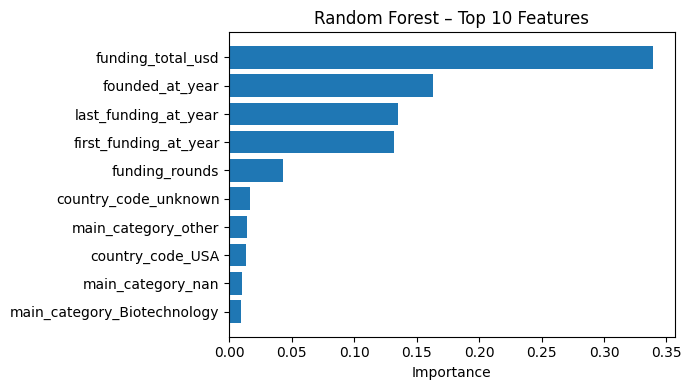

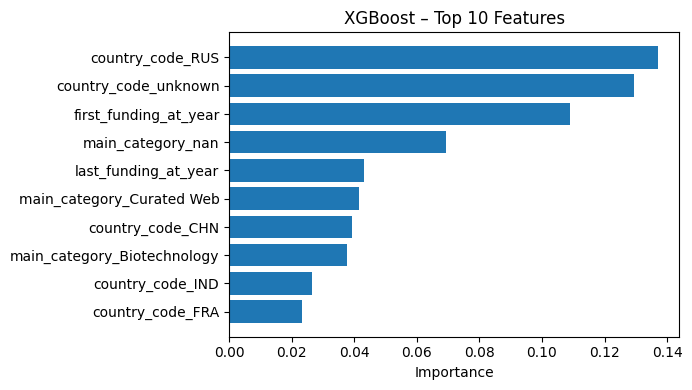

In [43]:
def plot_feature_importance(model, feature_names, title):
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:10]          
    plt.figure(figsize=(7, 4))
    plt.barh(range(len(idx)), importances[idx][::-1])
    plt.yticks(range(len(idx)), np.array(feature_names)[idx][::-1])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf,  X_train.columns, "Random Forest – Top 10 Features")
plot_feature_importance(xgbc, X_train.columns, "XGBoost – Top 10 Features")


In [44]:
#now as we got important features for each model we made , now lets make .pkl files to make our streamlit app
import joblib

joblib.dump(rf, 'rf_model.pkl')

joblib.dump(xgbc, 'xgb_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

joblib.dump(X_train.columns.tolist(), 'column_order.pkl')

['column_order.pkl']